# Detection validation - IoU

Score `detect_mask` against the generator's ground-truth masks, and
compare the two response signals (`edge_density` vs `local_std`).

In [1]:
import sys
sys.path.insert(0, "..")

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from src.detection.validate import evaluate_detection
from src.detection.detect import detect_mask
from src.data.loading import load_image
from src.data.mask import load_mask, overlay_mask

In [3]:
DATA_DIR = Path("../data/generated")

## Signal comparison

In [4]:
ed = evaluate_detection(DATA_DIR, signal="edge_density")
ls = evaluate_detection(DATA_DIR, signal="local_std")
print(f"edge_density  mean IoU: {ed['mean_iou']:.3f}")
print(f"local_std     mean IoU: {ls['mean_iou']:.3f}")

edge_density  mean IoU: 0.334
local_std     mean IoU: 0.452


In [5]:
for sig in ("edge_density", "local_std"):
    for sel in ("largest", "densest"):
        r = evaluate_detection(DATA_DIR, signal=sig, selection=sel)
        print(f"{sig:13s} + {sel:8s}: mean IoU {r['mean_iou']:.3f}")

edge_density  + largest : mean IoU 0.334
edge_density  + densest : mean IoU 0.331
local_std     + largest : mean IoU 0.452
local_std     + densest : mean IoU 0.362


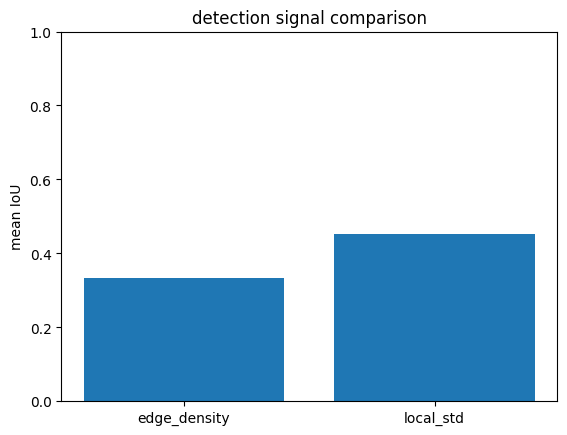

In [6]:
plt.bar(["edge_density", "local_std"], [ed["mean_iou"], ls["mean_iou"]])
plt.ylabel("mean IoU"); plt.ylim(0, 1)
plt.title("detection signal comparison");

## Per-image IoU distribution (better signal)

Text(0.5, 1.0, 'per-image IoU (local_std)')

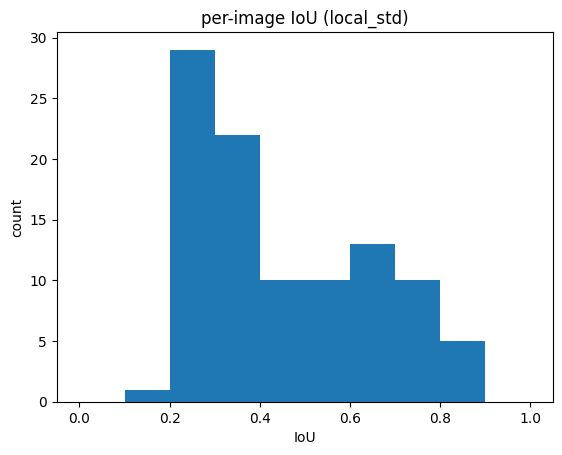

In [7]:
better = ls if ls["mean_iou"] >= ed["mean_iou"] else ed
signal = "local_std" if better is ls else "edge_density"
plt.hist(better["ious"], bins=10, range=(0, 1))
plt.xlabel("IoU")
plt.ylabel("count")
plt.title(f"per-image IoU ({signal})")

## Worst cases

Where detection struggles - usually cluttered backgrounds. Good report
material: shows the method's limits honestly.

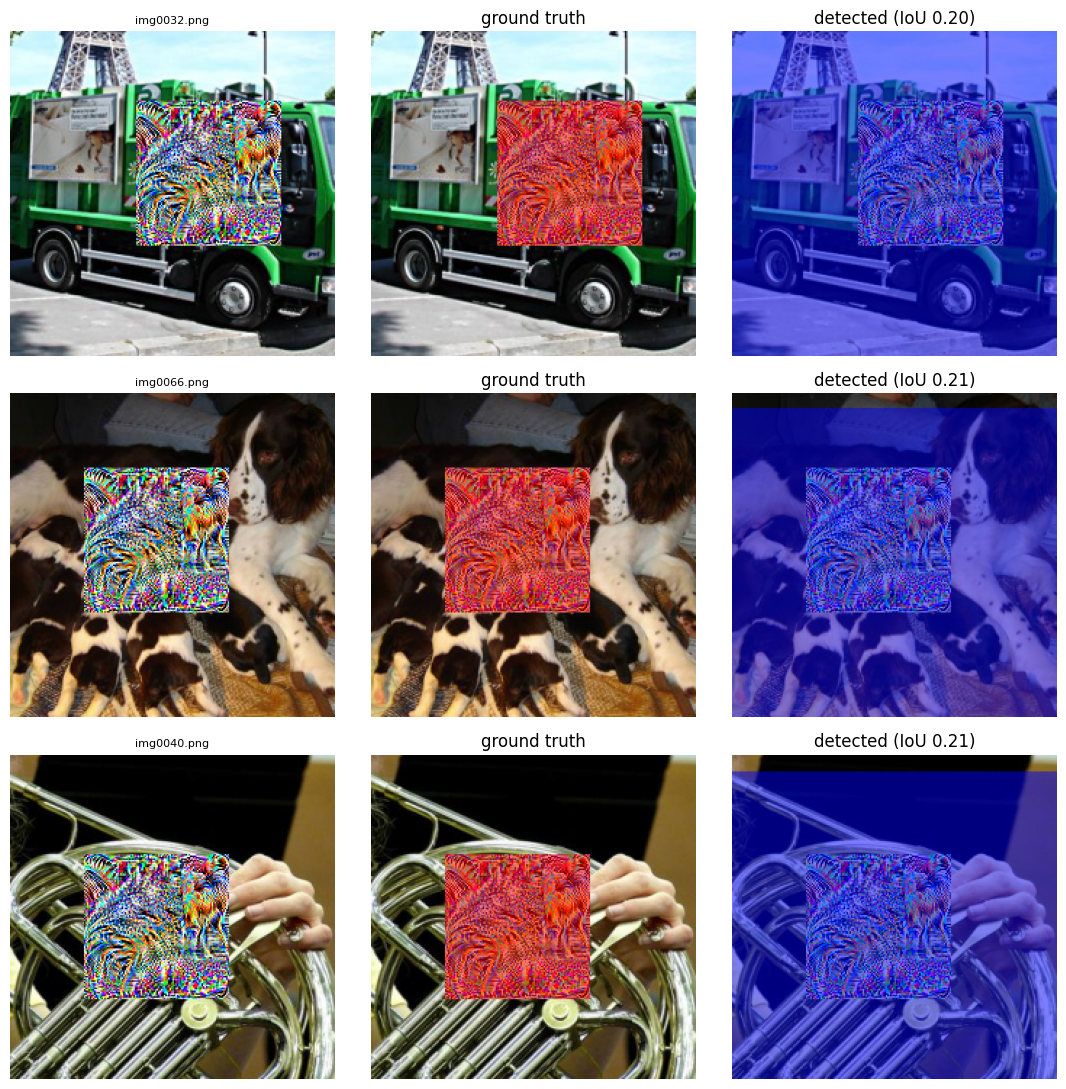

In [8]:
order = np.argsort(better["ious"])
worst = order[:3]

fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for r, idx in enumerate(worst):
    name = better["names"][idx]
    img = load_image(DATA_DIR / "patched" / name)
    gt = load_mask(DATA_DIR / "mask" / name)
    pred = detect_mask(img, signal=signal)
    axes[r, 0].imshow(img); axes[r, 0].set_title(name, fontsize=8)
    axes[r, 1].imshow(overlay_mask(img, gt))
    axes[r, 1].set_title("ground truth")
    axes[r, 2].imshow(overlay_mask(img, pred, color=(0, 0, 255)))
    axes[r, 2].set_title(f"detected (IoU {better['ious'][idx]:.2f})")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()